<a href="https://colab.research.google.com/github/riyamotwanii/AML-Assignments/blob/main/Exp_4_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== ORIGINAL DATASET ==========

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

========== SCALED DATA ==========

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.900681          1.019004          -1.340227         -1.315444
1          -1.143017         -0.131979          -1.340227         -1.315444
2          -1.385353          0.328414          -1.397064         -1.315444
3          -1.506521          0.098217          -1.283389         -1.3154

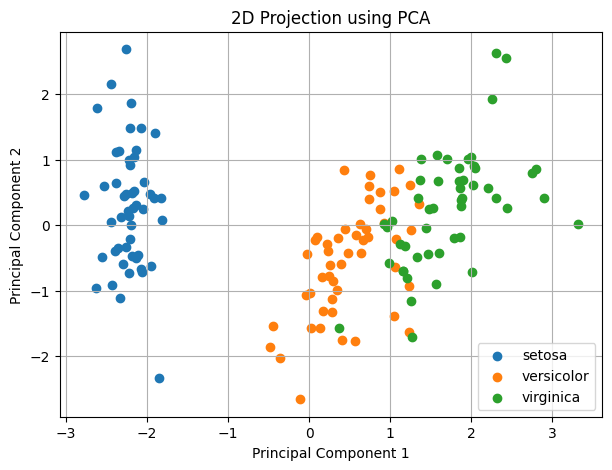

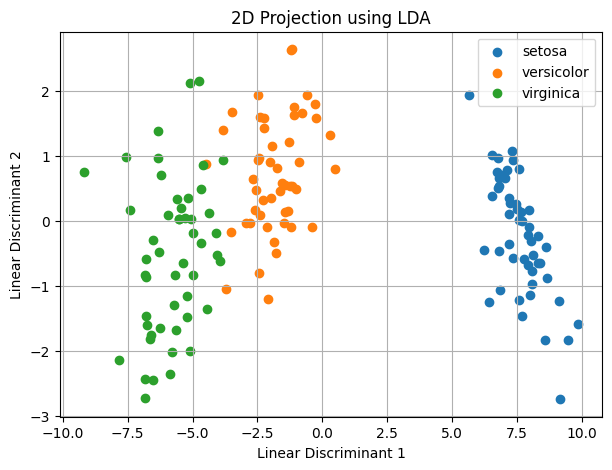


VISUAL DIFFERENCE COMMENT

1. PCA focuses on maximizing variance in data.
2. LDA focuses on maximizing class separability.
3. PCA may show overlapping classes.
4. LDA usually provides better class separation.
5. LDA often gives higher classification accuracy.


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



iris = load_iris()

# Features and target
X = iris.data
y = iris.target

# Feature names
feature_names = iris.feature_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=feature_names)

df['target'] = y

print("========== ORIGINAL DATASET ==========\n")
print(df.head())



scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\n========== SCALED DATA ==========\n")
print(pd.DataFrame(X_scaled, columns=feature_names).head())



print("\n================================================")
print("APPLYING PCA")
print("================================================\n")

# Reduce to 2 components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# PCA DataFrame
pca_df = pd.DataFrame(
    X_pca,
    columns=['PCA_Component_1', 'PCA_Component_2']
)

print("Reduced Features using PCA:\n")
print(pca_df.head())

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# ============================================================
# STEP 5 : APPLY LDA
# ============================================================

print("\n================================================")
print("APPLYING LDA")
print("================================================\n")

# Reduce to 2 components
lda = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda.fit_transform(X_scaled, y)

# LDA DataFrame
lda_df = pd.DataFrame(
    X_lda,
    columns=['LDA_Component_1', 'LDA_Component_2']
)

print("Reduced Features using LDA:\n")
print(lda_df.head())



X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

X_train_lda, X_test_lda, y_train2, y_test2 = train_test_split(
    X_lda,
    y,
    test_size=0.2,
    random_state=42
)


print("\n================================================")
print("CLASSIFICATION USING PCA FEATURES")
print("================================================\n")

model_pca = LogisticRegression()

model_pca.fit(X_train_pca, y_train)

y_pred_pca = model_pca.predict(X_test_pca)

pca_accuracy = accuracy_score(y_test, y_pred_pca)

print("Accuracy using PCA :", round(pca_accuracy * 100, 2), "%")



print("\n================================================")
print("CLASSIFICATION USING LDA FEATURES")
print("================================================\n")

model_lda = LogisticRegression()

model_lda.fit(X_train_lda, y_train2)

y_pred_lda = model_lda.predict(X_test_lda)

lda_accuracy = accuracy_score(y_test2, y_pred_lda)

print("Accuracy using LDA :", round(lda_accuracy * 100, 2), "%")


print("\n================================================")
print("ACCURACY COMPARISON")
print("================================================\n")

comparison = pd.DataFrame({
    'Method': ['PCA', 'LDA'],
    'Accuracy': [pca_accuracy, lda_accuracy]
})

print(comparison)



plt.figure(figsize=(7,5))

for target in np.unique(y):
    plt.scatter(
        X_pca[y == target, 0],
        X_pca[y == target, 1],
        label=iris.target_names[target]
    )

plt.title("2D Projection using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()

plt.show()

# ============================================================
# STEP 11 : PLOT LDA 2D PROJECTION
# ============================================================

plt.figure(figsize=(7,5))

for target in np.unique(y):
    plt.scatter(
        X_lda[y == target, 0],
        X_lda[y == target, 1],
        label=iris.target_names[target]
    )

plt.title("2D Projection using LDA")
plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.legend()
plt.grid()

plt.show()

# ============================================================
# STEP 12 : VISUAL DIFFERENCE COMMENT
# ============================================================

print("\n================================================")
print("VISUAL DIFFERENCE COMMENT")
print("================================================\n")

print("1. PCA focuses on maximizing variance in data.")
print("2. LDA focuses on maximizing class separability.")
print("3. PCA may show overlapping classes.")
print("4. LDA usually provides better class separation.")
print("5. LDA often gives higher classification accuracy.")